In [155]:
import pandas as pd
import matplotlib.pyplot as plt

model_variant = "yolo11n.pt"
IMG_COUNT = 8977
score = "precision"
resolutions = np.array([416, 640, 1280])
training_results = pd.read_csv("results.csv")
untrained_results = pd.read_csv("results_no_train.csv")
rosenfeld_estimates = pd.read_csv("rosenfeld_estimates.csv")
model_sizes = pd.read_csv("model_sizes.csv", index_col="model_variant")

In [156]:
def envelope(n, alpha, b, m, beta, c_inf, eps_0, eta):
    argument = n **(-alpha) + b * m ** (-beta) + c_inf
    return eps_0 * np.abs(argument) / np.sqrt(argument ** 2 + eta ** 2)

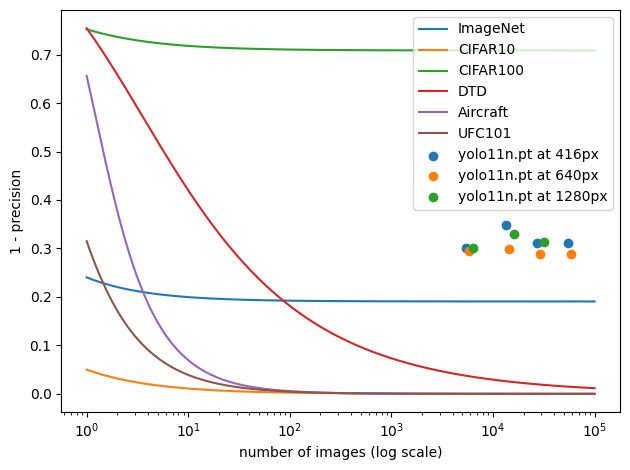

In [158]:

import numpy as np
import matplotlib.pyplot as plt

alpha =  rosenfeld_estimates["alpha"].to_numpy()
b = rosenfeld_estimates["b"].to_numpy()
beta = rosenfeld_estimates["beta"].to_numpy()
c_inf = rosenfeld_estimates["c_inf"].to_numpy()
eta = rosenfeld_estimates["eta"].to_numpy()
model_size = model_sizes.loc[model_variant].to_numpy()[0]

# Define x range (log-spaced)
x = np.logspace(0, 5, 300)[:, None]
# Alpha values
predicted_errors = envelope(x,
   alpha,
   b,
       model_size,
    beta,
     c_inf,
      0.99,
       eta)

for k in range(alpha.shape[0]):
   plt.plot(x[:, 0], predicted_errors[:,k], label=f"{rosenfeld_estimates["dataset"][k]}")

for resolution in resolutions:
   mask = (training_results["model_variant"] == model_variant) & (training_results["resolution"] == resolution)
   subset = training_results[mask]
   n = subset["dataset_fraction"] * IMG_COUNT * np.log(resolution)
   plt.scatter(n, 1 - subset[score], label=f"{model_variant} at {resolution}px")

plt.xscale("log")
plt.xlabel("number of images (log scale)")
plt.ylabel(f"1 - {score}")
plt.legend()
plt.tight_layout()
plt.show()

